/tmp/ipykernel_2089081/2634341415.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Single community LFR', 'Fuzzy LFR', 'Clear LFR'], fontsize=7)
/tmp/ipykernel_2089081/2634341415.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Single community LFR', 'Fuzzy LFR', 'Clear LFR'], fontsize=7)


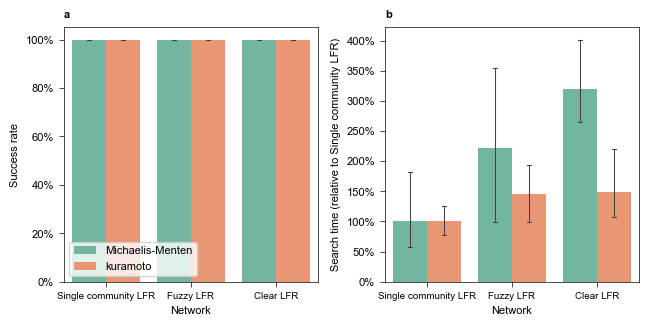

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nd2.utils.plot import get_fig

data = pd.read_json('./result/community_network.json')

data['model'] = data['name'].apply(lambda x: x.split('_')[0])
data['network'] = data['name'].apply(lambda x: x.split('_')[1])
data['model'] = data['model'].apply(lambda x: 'Michaelis-Menten' if x == 'MM' else x)
data['time'] = (data.set_index('model')['time'] / data[data.network == 'BA100'].groupby('model')['time'].mean()).values

from matplotlib.ticker import PercentFormatter

fi, fig, axes = get_fig(1, 2, FW=18, fontsize=8, dpi=100, LM=6, TM=6, BM=6, RM=6, VS=6, HS=6)

ax = axes[0]
data['success'] = (data['ACC4'] > 0.9)
sns.barplot(data, x='network', y='success', hue='model', capsize=0.1, palette='Set2', ax=ax)
ax.set_xlabel('Network')
ax.set_ylabel('Success rate')
ax.set_xticklabels(['Single community LFR', 'Fuzzy LFR', 'Clear LFR'], fontsize=7)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.text(0, 1.03, 'a', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.legend_.set_title(None)
# ax.legend(loc='upper left')

ax = axes[1]
sns.barplot(data, x='network', y='time', hue='model', capsize=0.1, palette='Set2', ax=ax)
ax.set_xlabel('Network')
ax.set_ylabel('Search time (relative to Single community LFR)')
ax.set_xticklabels(['Single community LFR', 'Fuzzy LFR', 'Clear LFR'], fontsize=7)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.text(0, 1.03, 'b', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.legend_.remove()

fig.savefig('./plot/community_network/Community_network_result.pdf', bbox_inches='tight', dpi=600)

In [4]:
import numpy as np
import networkx as nx

def get_pos(G, community, ratio=0.3, overlap=False):
    from collections import defaultdict
    # 分组：节点 -> 社区
    communities = defaultdict(list)
    for node, comm in zip(community['node'], community['community']):
        communities[comm].append(node)

    # 第一步：构建“社区图”
    meta_graph = nx.Graph()
    community_ids = list(communities.keys())
    if overlap:
        community_ids = sum(map(list, community_ids), [])

    # 初始化社区图
    for i in community_ids:
        meta_graph.add_node(i)

    # 统计社区之间的连接
    for u, v in G.edges():
        cu = community.set_index('node').loc[u].item()
        cv = community.set_index('node').loc[v].item()
        if overlap:
            for i in cu:
                for j in cv:
                    if i != j:
                        if meta_graph.has_edge(i, j):
                            meta_graph[i][j]['weight'] += 1
                        else:
                            meta_graph.add_edge(i, j, weight=1)
        else:
            if cu != cv:
                if meta_graph.has_edge(cu, cv):
                    meta_graph[cu][cv]['weight'] += 1
                else:
                    meta_graph.add_edge(cu, cv, weight=1)

    # 对社区图进行 spring_layout，得到“每个社区”的中心坐标
    meta_pos = nx.spring_layout(meta_graph, weight='weight', seed=42)

    if overlap:
        # 对于重叠社区，使用原始节点的坐标平均值
        for i in communities:
            meta_pos[i] = np.mean([meta_pos[c] for c in i], axis=0)

    # 第二步：对子图布局 + 平移
    pos = {}
    for comm_id, nodes in communities.items():
        subG = G.subgraph(nodes)
        sub_pos = nx.spring_layout(subG, seed=42)

        # 中心位置
        center = meta_pos[comm_id]

        # 平移：将子图中心移到社区图对应位置
        for node in sub_pos:
            pos[node] = ratio * sub_pos[node] + center

    return pos

def load_data(nse, nmc, ratio=0.7):
    network = pd.read_csv(nse, sep='\t', comment='#', header=None)
    network.columns=['source', 'target', 'weight']

    community = pd.read_csv(nmc, sep='\t', comment='#', header=None)
    community.columns=['node', 'community']

    G = nx.from_pandas_edgelist(network, 'source', 'target')
    pos = get_pos(G, community, ratio=ratio/np.sqrt(community['community'].nunique()))
    node_color=community.set_index('node').loc[list(G.nodes()), 'community']

    return G, pos, node_color

def plot_first_N(data, ax, N, label):
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list('my_hsv', ['#d63031', '#e17055', '#fdcb6e', '#00b894', '#00cec9', '#0984e3' ,'#6c5ce7', '#e84393'])
    if data[0].ndim == 1:
        data[0] = data[0][:, np.newaxis].repeat(data[1].shape[1], axis=1)
    for i in range(N):
        ax.plot(*[x[..., i] for x in data], label=f'{label} {i+1}', color=cmap(i/N))
    for i in range(N, data[0].shape[-1]):
        ax.plot(*[x[..., i] for x in data], color='#b2bec3', alpha=0.3, zorder=-100000)


/tmp/ipykernel_2089081/2464718871.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  set2_cmap = plt.cm.get_cmap('Set2', len(communities['community'].unique()))
/tmp/ipykernel_2089081/2464718871.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  set2_cmap = plt.cm.get_cmap('Set2', len(communities['community'].unique()))
/tmp/ipykernel_2089081/2464718871.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  set2_cmap = plt.cm.get_cmap('Set2', len(communities['

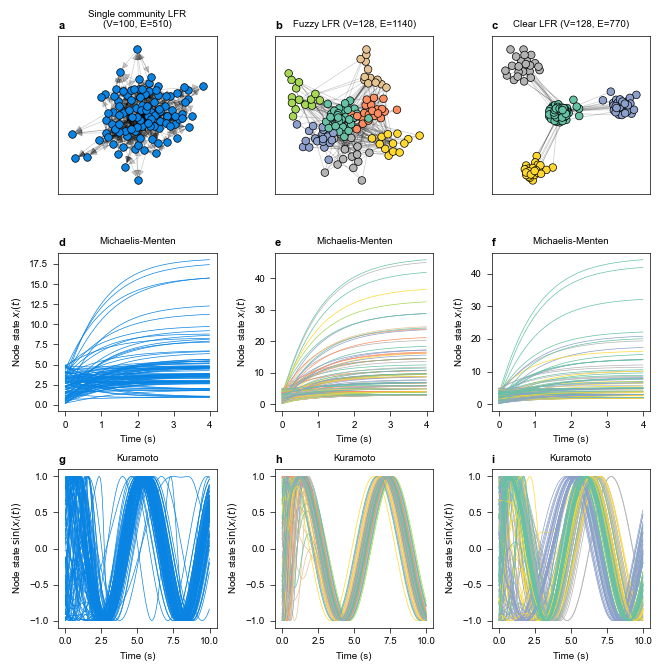

In [7]:
import numpy as np
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

fi, fig, axes = get_fig(3, 3, FW=18, A_ratio=1, LM=6, RM=6, TM=6, BM=6, dpi=100, lw=0.5)


ax = axes[0]
network = np.array(json.load(open('./data/community_network/MM_BA100.json', 'r'))['A'])
G = nx.from_numpy_array(network, create_using=nx.DiGraph)
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_edges(G, pos, ax=ax, node_size=30, width=0.5, edge_color='k', alpha=0.2)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, edgecolors='k', linewidths=0.5, node_color='#0984e3')
ax.set_title(f'Single community LFR\n(V={G.number_of_nodes()}, E={G.number_of_edges()})')
ax.text(0, 1.03, 'a', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

ax = axes[3]
data = json.load(open('./data/community_network/MM_BA100.json', 'r'))
time = np.arange(400) * 0.01
# plot_first_N([time, np.array(data['x'])], ax=ax, N=10, label='Node')
ax.plot(time, np.array(data['x']), color='#0984e3')
ax.set_title(f'Michaelis-Menten')
ax.text(0, 1.03, 'd', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Node state $x_i(t)$')

ax = axes[6]
data = json.load(open('./data/community_network/KUR_BA100.json', 'r'))
time = np.arange(1000) * 0.01
# plot_first_N([time, np.sin(data['x'])], ax=ax, N=10, label='Node')
ax.plot(time, np.sin(data['x']), color='#0984e3')
ax.set_title(f'Kuramoto')
ax.text(0, 1.03, 'g', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Node state $\\sin(x_i(t))$')



ax = axes[1]
network = np.array(json.load(open('./data/community_network/MM_fuzzy.json', 'r'))['A'])
G = nx.from_numpy_array(network)
communities = pd.DataFrame([(idx, n) for idx, nodes in enumerate(greedy_modularity_communities(G)) for n in nodes])
communities.columns = ['community', 'node']
pos = get_pos(G, communities, ratio=0.5)
node_color = communities.set_index('node').loc[list(G.nodes()), 'community']
# G, pos, node_color = load_data('~/LFR-Benchmark_UndirWeightOvp/fuzzy.nse', '~/LFR-Benchmark_UndirWeightOvp/fuzzy.nmc', ratio=1.0)
nx.draw_networkx_edges(G, pos, ax=ax, width=0.5, edge_color='k', alpha=0.2)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, edgecolors='k', linewidths=0.5, node_color=node_color, cmap='Set2')
ax.set_title(f'Fuzzy LFR (V={G.number_of_nodes()}, E={2*G.number_of_edges()})')
ax.text(0, 1.03, 'b', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

ax = axes[4]
data = json.load(open('./data/community_network/MM_fuzzy.json', 'r'))
time = np.arange(400) * 0.01
# plot_first_N([time, np.array(data['x'])], ax=ax, N=10, label='Node')
set2_cmap = plt.cm.get_cmap('Set2', len(communities['community'].unique()))
for idx, x in enumerate(np.array(data['x']).T):
    ax.plot(time, x, color=set2_cmap(communities.set_index('node').loc[idx, 'community']))
ax.set_title(f'Michaelis-Menten')
ax.text(0, 1.03, 'e', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Node state $x_i(t)$')

ax = axes[7]
data = json.load(open('./data/community_network/KUR_fuzzy.json', 'r'))
time = np.arange(1000) * 0.01
# plot_first_N([time, np.sin(data['x'])], ax=ax, N=10, label='Node')
set2_cmap = plt.cm.get_cmap('Set2', len(communities['community'].unique()))
for idx, x in enumerate(np.array(data['x']).T):
    ax.plot(time, np.sin(x), color=set2_cmap(communities.set_index('node').loc[idx, 'community']))
ax.set_title(f'Kuramoto')
ax.text(0, 1.03, 'h', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Node state $\\sin(x_i(t))$')



ax = axes[2]
network = np.array(json.load(open('./data/community_network/MM_clear.json', 'r'))['A'])
G = nx.from_numpy_array(network)
communities = pd.DataFrame([(idx, n) for idx, nodes in enumerate(greedy_modularity_communities(G)) for n in nodes])
communities.columns = ['community', 'node']
pos = get_pos(G, communities, ratio=0.3)
node_color = communities.set_index('node').loc[list(G.nodes()), 'community']
# G, pos, node_color = load_data('~/LFR-Benchmark_UndirWeightOvp/clear.nse', '~/LFR-Benchmark_UndirWeightOvp/clear.nmc', ratio=0.6)
nx.draw_networkx_edges(G, pos, ax=ax, width=0.5, edge_color='k', alpha=0.2)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, edgecolors='k', linewidths=0.5, node_color=node_color, cmap='Set2')
ax.set_title(f'Clear LFR (V={G.number_of_nodes()}, E={2*G.number_of_edges()})')
ax.text(0, 1.03, 'c', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

ax = axes[5]
data = json.load(open('./data/community_network/MM_clear.json', 'r'))
time = np.arange(400) * 0.01
# plot_first_N([time, np.array(data['x'])], ax=ax, N=10, label='Node')
set2_cmap = plt.cm.get_cmap('Set2', len(communities['community'].unique()))
for idx, x in enumerate(np.array(data['x']).T):
    ax.plot(time, x, color=set2_cmap(communities.set_index('node').loc[idx, 'community']))
ax.set_title(f'Michaelis-Menten')
ax.text(0, 1.03, 'f', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Node state $x_i(t)$')

ax = axes[8]
data = json.load(open('./data/community_network/KUR_clear.json', 'r'))
time = np.arange(1000) * 0.01
# plot_first_N([time, np.sin(data['x'])], ax=ax, N=10, label='Node')
set2_cmap = plt.cm.get_cmap('Set2', len(communities['community'].unique()))
for idx, x in enumerate(np.array(data['x']).T):
    ax.plot(time, np.sin(x), color=set2_cmap(communities.set_index('node').loc[idx, 'community']))
ax.set_title(f'Kuramoto')
ax.text(0, 1.03, 'i', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Node state $\\sin(x_i(t))$')

fig.savefig('./plot/community_network/Community_network_demo.pdf', bbox_inches='tight', dpi=600)